In [ ]:
import torch
print("=" * 60)
print("  Zenith v29.0 — 3.2M Cell Foundation Model Training")
print("=" * 60)
print(f"  GPU:  {torch.cuda.get_device_name(0)}")
print(f"  CUDA: {torch.version.cuda}")
print("=" * 60)

  Zenith v29.0 — 3.2M Cell Foundation Model Training
  GPU:  NVIDIA A100-SXM4-80GB
  CUDA: 12.8


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 2: Install Dependencies (~2 minutes)
# ═══════════════════════════════════════════════════════════════
!pip install -q cellxgene-census scanpy scvi-tools tiledbsoma
print("\n✅ All dependencies installed successfully.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 6.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 91.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 699.1/699.1 kB 54.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.3/22.3 MB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 176.0/176.0 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 848.6/848.6 kB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 149.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 151.9/151.9 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 73.0 MB/s eta 0:00:00

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 3: Mount Google Drive for Checkpoint Safety
# ═══════════════════════════════════════════════════════════════
from google.colab import drive
import os

drive.mount('/content/drive')

CHECKPOINT_DIR = "/content/drive/MyDrive/zenith_v29_checkpoints/"
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
print(f"\n✅ Google Drive mounted.")
print(f"   Checkpoints will save to: {CHECKPOINT_DIR}")

Mounted at /content/drive

✅ Google Drive mounted.
   Checkpoints will save to: /content/drive/MyDrive/zenith_v29_checkpoints/


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4: Stream ALL 3.2M+ Cardiac Cells from CELLxGENE Census
# ⏱️ Estimated time: 10–30 minutes
# ═══════════════════════════════════════════════════════════════
import cellxgene_census
import tiledbsoma
import time

print("Opening CELLxGENE Census (latest stable release)...")
census = cellxgene_census.open_soma()

obs_filter = (
    "is_primary_data == True and "
    "disease == 'normal' and "
    "(tissue == 'heart' or tissue == 'heart left ventricle' or "
    "tissue == 'heart right ventricle' or tissue == 'interventricular septum' or "
    "tissue == 'cardiac atrium' or tissue == 'cardiac ventricle' or "
    "tissue == 'left cardiac atrium' or tissue == 'right cardiac atrium' or "
    "tissue == 'myocardium' or tissue == 'aorta' or "
    "tissue == 'coronary artery' or tissue == 'pericardium')"
)

print(f"Streaming ALL human cardiac/vascular cells...")
print(f"This will take 10–30 minutes. Do NOT close this tab.\n")
t0 = time.time()

adata = cellxgene_census.get_anndata(
    census,
    organism="Homo sapiens",
    obs_value_filter=obs_filter,
    column_names={
        "obs": ["dataset_id", "donor_id", "suspension_type", "cell_type", "tissue"],
        "var": ["feature_name"],
    },
)

census.close()
elapsed = (time.time() - t0) / 60

print("=" * 60)
print(f"  ✅ STREAMING COMPLETE")
print(f"     Cells:  {adata.n_obs:,}")
print(f"     Genes:  {adata.n_vars:,}")
print(f"     Time:   {elapsed:.1f} minutes")
print("=" * 60)

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
INFO:cellxgene_census:The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Opening CELLxGENE Census (latest stable release)...
Streaming ALL human cardiac/vascular cells...
This will take 10–30 minutes. Do NOT close this tab.



/tmp/ipykernel_3574/1065400033.py:27: FutureWarning: The argument `column_names` is deprecated and will be removed in a future release. Please use `obs_column_names` and `var_column_names` instead.
  adata = cellxgene_census.get_anndata(
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  ✅ STREAMING COMPLETE
     Cells:  1,237,767
     Genes:  61,497
     Time:   1.7 minutes


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5: Quality Control (QC) Filtering
# ═══════════════════════════════════════════════════════════════
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

# Standardise gene names
adata.var_names = adata.var["feature_name"].astype(str)
adata.var_names_make_unique()

# Annotate mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")

# Calculate QC metrics
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

# Apply QC filters (Luecken et al. 2022)
n_before = adata.n_obs
adata = adata[
    (adata.obs["n_genes_by_counts"] >= 200) &
    (adata.obs["n_genes_by_counts"] <= 7_000) &
    (adata.obs["total_counts"] >= 500) &
    (adata.obs["pct_counts_mt"] <= 20)
].copy()

print(f"QC Filter: {n_before:,} → {adata.n_obs:,} cells ({n_before - adata.n_obs:,} removed)")
print(f"\n{'='*60}")
print(f"  Top 15 Cell Types:")
print(f"{'='*60}")
print(adata.obs["cell_type"].value_counts().head(15).to_string())
print(f"\n  Datasets: {adata.obs['dataset_id'].nunique()}")
print(f"  Donors:   {adata.obs['donor_id'].nunique()}")

/tmp/ipykernel_3574/2752111361.py:11: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD115-1', 'SNORD115-2', 'SNORD115-3', 'SNORD115-4', 'SNORD115-5']
  adata.var_names_make_unique()


QC Filter: 1,237,767 → 1,095,740 cells (142,027 removed)

  Top 15 Cell Types:
cell_type
regular ventricular cardiac myocyte    214058
fibroblast                             180095
pericyte                               103076
cardiac muscle cell                     77547
regular atrial cardiac myocyte          67096
capillary endothelial cell              62853
endothelial cell                        54272
myeloid cell                            43806
unknown                                 32055
fibroblast of cardiac tissue            31336
smooth muscle cell                      29369
cardiac endothelial cell                26919
endothelial cell of artery              22081
mural cell                              19415
macrophage                              18579

  Datasets: 11
  Donors:   83


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6: Preprocessing — HVG Selection (6,000 genes)
# ⏱️ Estimated time: 5–15 minutes
# ═══════════════════════════════════════════════════════════════
sc.pp.filter_genes(adata, min_cells=10)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.var["ribo"] = (
    adata.var_names.str.startswith("RPL") |
    adata.var_names.str.startswith("RPS")
)

sc.pp.highly_variable_genes(
    adata, n_top_genes=6000, subset=False, flavor="seurat_v3",
    layer="counts", batch_key="dataset_id"
)

adata.var.loc[adata.var["mt"], "highly_variable"] = False
adata.var.loc[adata.var["ribo"], "highly_variable"] = False

adata.X = adata.layers["counts"].copy()
adata = adata[:, adata.var["highly_variable"]].copy()

for col in ["dataset_id", "donor_id", "suspension_type"]:
    adata.obs[col] = pd.Categorical(adata.obs[col].astype(str))

print(f"\n{'='*60}")
print(f"  ✅ PREPROCESSING COMPLETE")
print(f"     Training shape: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"{'='*60}")


  ✅ PREPROCESSING COMPLETE
     Training shape: 1,095,740 cells × 5,849 genes


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 4B: Stream ALL Cardiac Cells (Healthy + Diseased)
# ⏱️ Estimated time: 2–5 minutes
# ═══════════════════════════════════════════════════════════════
import cellxgene_census
import tiledbsoma
import time

print("Opening CELLxGENE Census...")
census = cellxgene_census.open_soma()

# NO disease filter — includes healthy + heart failure + cardiomyopathy + all
obs_filter = (
    "is_primary_data == True and "
    "(tissue == 'heart' or tissue == 'heart left ventricle' or "
    "tissue == 'heart right ventricle' or tissue == 'interventricular septum' or "
    "tissue == 'cardiac atrium' or tissue == 'cardiac ventricle' or "
    "tissue == 'left cardiac atrium' or tissue == 'right cardiac atrium' or "
    "tissue == 'myocardium' or tissue == 'aorta' or "
    "tissue == 'coronary artery' or tissue == 'pericardium')"
)

print("Streaming ALL cardiac cells (healthy + diseased)...")
print("Do NOT close this tab.\n")
t0 = time.time()

adata = cellxgene_census.get_anndata(
    census,
    organism="Homo sapiens",
    obs_value_filter=obs_filter,
    obs_column_names=[
        "dataset_id", "donor_id", "suspension_type",
        "cell_type", "tissue", "disease",
    ],
    var_column_names=["feature_name"],
)

census.close()
elapsed = (time.time() - t0) / 60

print("=" * 60)
print(f"  ✅ STREAMING COMPLETE")
print(f"     Cells:  {adata.n_obs:,}")
print(f"     Genes:  {adata.n_vars:,}")
print(f"     Time:   {elapsed:.1f} minutes")
print("=" * 60)
print(f"\n  Disease breakdown:")
print(adata.obs["disease"].value_counts().head(10).to_string())

The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.
INFO:cellxgene_census:The "stable" release is currently 2025-11-08. Specify 'census_version="2025-11-08"' in future calls to open_soma() to ensure data consistency.


Opening CELLxGENE Census...
Streaming ALL cardiac cells (healthy + diseased)...
Do NOT close this tab.



/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/usr/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


  ✅ STREAMING COMPLETE
     Cells:  2,105,588
     Genes:  61,497
     Time:   2.1 minutes

  Disease breakdown:
disease
normal                                             1237767
dilated cardiomyopathy                              482581
myocardial infarction                               169854
arrhythmogenic right ventricular cardiomyopathy     104496
myocarditis                                          62705
atherosclerosis                                      35395
non-compaction cardiomyopathy                        11632
hypertrophic cardiomyopathy                           1158
keloid                                                   0
kidney oncocytoma                                        0


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 5B: Quality Control (QC) Filtering — 2.1M cells
# ═══════════════════════════════════════════════════════════════
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp

adata.var_names = adata.var["feature_name"].astype(str)
adata.var_names_make_unique()
adata.var["mt"] = adata.var_names.str.startswith("MT-")
sc.pp.calculate_qc_metrics(adata, qc_vars=["mt"], percent_top=None, log1p=False, inplace=True)

n_before = adata.n_obs
adata = adata[
    (adata.obs["n_genes_by_counts"] >= 200) &
    (adata.obs["n_genes_by_counts"] <= 7_000) &
    (adata.obs["total_counts"] >= 500) &
    (adata.obs["pct_counts_mt"] <= 20)
].copy()

print(f"QC Filter: {n_before:,} → {adata.n_obs:,} cells ({n_before - adata.n_obs:,} removed)")
print(f"\n  Datasets: {adata.obs['dataset_id'].nunique()}")
print(f"  Donors:   {adata.obs['donor_id'].nunique()}")
print(f"\n  Disease breakdown after QC:")
print(adata.obs["disease"].value_counts().to_string())

/tmp/ipykernel_3574/1027953194.py:10: UserWarning: Suffix used (-[0-9]+) to deduplicate index values may make index values difficult to interpret. There values with a similar suffixes in the index. Consider using a different delimiter by passing `join={delimiter}`. Example key collisions generated by the make_index_unique algorithm: ['SNORD115-1', 'SNORD115-2', 'SNORD115-3', 'SNORD115-4', 'SNORD115-5']
  adata.var_names_make_unique()


QC Filter: 2,105,588 → 1,962,128 cells (143,460 removed)

  Datasets: 14
  Donors:   210

  Disease breakdown after QC:
disease
normal                                             1095740
dilated cardiomyopathy                              482264
myocardial infarction                               169750
arrhythmogenic right ventricular cardiomyopathy     104467
myocarditis                                          62684
atherosclerosis                                      34788
non-compaction cardiomyopathy                        11631
hypertrophic cardiomyopathy                            804


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 6B: Preprocessing — HVG Selection (6,000 genes)
# ⏱️ Estimated time: 5–10 minutes
# ═══════════════════════════════════════════════════════════════
sc.pp.filter_genes(adata, min_cells=10)
adata.layers["counts"] = adata.X.copy()
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)

adata.var["ribo"] = (
    adata.var_names.str.startswith("RPL") |
    adata.var_names.str.startswith("RPS")
)

sc.pp.highly_variable_genes(
    adata, n_top_genes=6000, subset=False, flavor="seurat_v3",
    layer="counts", batch_key="dataset_id"
)

adata.var.loc[adata.var["mt"], "highly_variable"] = False
adata.var.loc[adata.var["ribo"], "highly_variable"] = False

adata.X = adata.layers["counts"].copy()
adata = adata[:, adata.var["highly_variable"]].copy()

for col in ["dataset_id", "donor_id", "suspension_type", "disease"]:
    adata.obs[col] = pd.Categorical(adata.obs[col].astype(str))

print(f"\n{'='*60}")
print(f"  ✅ PREPROCESSING COMPLETE")
print(f"     Training shape: {adata.n_obs:,} cells × {adata.n_vars:,} genes")
print(f"     Donors: {adata.obs['donor_id'].nunique()}")
print(f"     Diseases: {adata.obs['disease'].nunique()}")
print(f"{'='*60}")


  ✅ PREPROCESSING COMPLETE
     Training shape: 1,962,128 cells × 5,858 genes
     Donors: 210
     Diseases: 8


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7: Train Zenith v29.0 Foundation Model
# ⏱️ Estimated time: 8–12 hours (A100 GPU)
# ⚠️ KEEP THIS BROWSER TAB OPEN
# ═══════════════════════════════════════════════════════════════
import scvi
import torch
import os
from pytorch_lightning.callbacks import ModelCheckpoint
import numpy as np
import scanpy as sc

# 1. Setup scVI AnnData with primary batch and secondary covariates
print("Configuring scVI data integration...")
scvi.model.SCVI.setup_anndata(
    adata,
    layer="counts",
    batch_key="dataset_id",
    categorical_covariate_keys=["donor_id", "suspension_type", "disease"]
)

# 2. Initialize the scVI Model (Scaled architecture for 2.1M cells)
print("\nInitializing Zenith v29.0 Foundation Model...")
model = scvi.model.SCVI(
    adata,
    n_hidden=1024,
    n_latent=64,
    n_layers=4,
    gene_likelihood="nb",
    encode_covariates=True,
    deeply_inject_covariates=False,
    use_layer_norm="both",
    use_batch_norm="none",
)

# Print model parameters summary
n_params = sum(p.numel() for p in model.module.parameters())
print(f"  ✓ Model initialized with {n_params:,} trainable parameters.")
print(f"  ✓ Architecture: 1024 hidden × 4 layers | 64 latent dimensions")

# 3. Configure Google Drive Checkpoint Callback (Saves every 10 epochs)
print(f"\nSetting up auto-checkpoints → {CHECKPOINT_DIR}")
checkpoint_callback = ModelCheckpoint(
    dirpath=CHECKPOINT_DIR,
    filename="zenith_v29_epoch_{epoch:03d}",
    every_n_epochs=10,
    save_top_k=-1,  # Keep all checkpoints
)

# 4. Start Model Training
print(f"\nStarting training (max 150 epochs, batch_size=2048)...")
model.train(
    max_epochs=150,
    batch_size=2048,
    early_stopping=True,
    early_stopping_patience=20,
    early_stopping_monitor="elbo_validation",
    check_val_every_n_epoch=5,
    train_size=0.90,
    plan_kwargs={
        "lr": 1e-3,
        "weight_decay": 1e-6,
        "eps": 1e-8,
    },
    callbacks=[checkpoint_callback]  # Pass callbacks directly as a top-level argument
)

# 5. Save the Final Model and Gene Var Schema
FINAL_DIR = os.path.join(CHECKPOINT_DIR, "final_model")
print(f"\nSaving final model to Google Drive → {FINAL_DIR}")
model.save(FINAL_DIR, overwrite=True)

# Save gene schema (required for aligning future validation datasets)
ref_adata = sc.AnnData(
    X   = np.zeros((1, adata.n_vars), dtype=np.float32),
    var = adata.var.copy(),
    dtype=np.float32
)
ref_adata.write_h5ad(os.path.join(FINAL_DIR, "var_schema.h5ad"))

print(f"\n{'='*60}")
print(f"  ✅ TRAINING COMPLETE — Zenith v29.0")
print(f"     Cells:  {adata.n_obs:,}")
print(f"     Genes:  {adata.n_vars:,}")
print(f"     Model:  {FINAL_DIR}")
print(f"{'='*60}")

Configuring scVI data integration...

Initializing Zenith v29.0 Foundation Model...


INFO:pytorch_lightning.utilities.rank_zero:GPU available: True (cuda), used: True
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:pytorch_lightning.utilities.rank_zero:You are using a CUDA device ('NVIDIA A100-SXM4-80GB') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision


  ✓ Model initialized with 37,234,698 trainable parameters.
  ✓ Architecture: 1024 hidden × 4 layers | 64 latent dimensions

Setting up auto-checkpoints → /content/drive/MyDrive/zenith_v29_checkpoints/

Starting training (max 150 epochs, batch_size=2048)...


INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training:   0%|          | 0/150 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/lightning/pytorch/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/connectors/data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=150` reached.



Saving final model to Google Drive → /content/drive/MyDrive/zenith_v29_checkpoints/final_model


/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


ValueError: DataFrame.index.name ('feature_name') is also used by a column whose values are different. This is not supported. Please make sure the values are the same, or use a different name.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 7B: Save Var Schema (Fixing index clash)
# ═══════════════════════════════════════════════════════════════
import os
import numpy as np
import scanpy as sc

# 1. Define final model directory on Google Drive
FINAL_DIR = "/content/drive/MyDrive/zenith_v29_checkpoints/final_model"

# 2. Copy the gene variables dataframe
ref_var = adata.var.copy()

# 3. Clean up the index name conflict
ref_var.index.name = None

# 4. Create and save the reference AnnData
ref_adata = sc.AnnData(
    X   = np.zeros((1, adata.n_vars), dtype=np.float32),
    var = ref_var,
    dtype=np.float32
)
ref_adata.write_h5ad(os.path.join(FINAL_DIR, "var_schema.h5ad"))
print("✅ var_schema.h5ad saved successfully in the final_model folder!")

/usr/local/lib/python3.12/dist-packages/legacy_api_wrap/__init__.py:88: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  return fn(*args_all, **kw)


✅ var_schema.h5ad saved successfully in the final_model folder!


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Scientific Validation of Zenith v29.0
# ⏱️ Estimated time: 5–10 minutes
# ═══════════════════════════════════════════════════════════════
import os
import json
import datetime
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Define paths on Google Drive
FINAL_DIR = "/content/drive/MyDrive/zenith_v29_checkpoints/final_model"
REPORT_FILE = os.path.join(FINAL_DIR, "validation_report.json")
UMAP_FILE = os.path.join(FINAL_DIR, "umap_latent.h5ad")

# Marker genes for cardiac cell types
MARKER_GENES = {
    "cardiomyocyte":    ["MYH7", "MYH6", "TNNT2", "ACTC1", "TTN"],
    "fibroblast":       ["COL1A1", "COL3A1", "VIM", "DCN", "POSTN"],
    "endothelial":      ["PECAM1", "CDH5", "VWF", "CLDN5", "ENG"],
    "smooth_muscle":    ["ACTA2", "MYH11", "TAGLN", "CNN1", "SMTN"],
    "macrophage":       ["CD68", "CD14", "CSF1R", "AIF1", "MRC1"],
}

# 2. Subsample to 50,000 cells for fast CPU validation (avoiding long computations)
print("Subsampling to 50,000 cells for fast UMAP and mixing checks...")
np.random.seed(42)
val_idx = np.random.choice(adata.n_obs, size=min(50000, adata.n_obs), replace=False)
val_idx.sort()
adata_val = adata[val_idx].copy()
print(f"  ✓ Validation subset shape: {adata_val.n_obs:,} cells")

# 3. Extract Latent Space
print("\nExtracting latent representations...")
Z = model.get_latent_representation(adata=adata_val)
adata_val.obsm["X_scVI"] = Z
print(f"  ✓ Latent representation extracted: {Z.shape}")

# 4. Run UMAP and Clustering
print("\nComputing neighbors and UMAP projection...")
sc.pp.neighbors(adata_val, use_rep="X_scVI", n_neighbors=15, metric="cosine")
sc.tl.umap(adata_val, min_dist=0.3, spread=1.0, random_state=42)
sc.tl.leiden(adata_val, resolution=0.5, random_state=42, key_added="leiden_scvi")
print(f"  ✓ Leiden clusters: {adata_val.obs['leiden_scvi'].nunique()}")

# 5. Compute Biological Preservation (Silhouette Score)
print("\nCalculating Silhouette score for cell types...")
unique_labels = adata_val.obs["cell_type"].unique()
sampled_indices = []
for label in unique_labels:
    label_idx = np.where(adata_val.obs["cell_type"] == label)[0]
    n_draw = min(300, len(label_idx))
    np.random.seed(42)
    draw = np.random.choice(label_idx, size=n_draw, replace=False)
    sampled_indices.extend(draw)
sampled_indices = np.array(sampled_indices)
np.random.shuffle(sampled_indices)

sil = silhouette_score(
    Z[sampled_indices],
    adata_val.obs["cell_type"].iloc[sampled_indices].values,
    metric="euclidean"
)
print(f"  ✓ Silhouette score (cell types): {sil:.4f}  (>0.2 = good biology preserved)")

# 6. Compute Batch Integration (Batch Mixing Score)
print("\nCalculating batch mixing score...")
n_sample = min(5000, len(adata_val.obs["dataset_id"]))
np.random.seed(42)
mix_idx = np.random.choice(len(adata_val.obs["dataset_id"]), n_sample, replace=False)
X_sub = Z[mix_idx]
y_sub = pd.Categorical(adata_val.obs["dataset_id"].iloc[mix_idx].values)
global_props = y_sub.value_counts() / y_sub.value_counts().sum()
weights = {k: 1.0 / (prop + 1e-9) for k, prop in global_props.items()}

nn = NearestNeighbors(n_neighbors=50, metric="euclidean", n_jobs=-1)
nn.fit(X_sub)
_, indices = nn.kneighbors(X_sub)
entropies = []
for i, nbrs in enumerate(indices):
    neighbor_batches = [y_sub[j] for j in nbrs]
    weighted_counts = {b: sum(nb == b for nb in neighbor_batches) * weights[b] for b in y_sub.categories}
    total_weighted = sum(weighted_counts.values()) + 1e-9
    probs = [weighted_counts[b] / total_weighted for b in y_sub.categories]
    entropy = -sum(p * np.log2(p + 1e-15) for p in probs)
    entropies.append(entropy / np.log2(len(y_sub.categories)))
mix = float(np.mean(entropies))
print(f"  ✓ Batch mixing score: {mix:.4f}  (>0.5 = good batch integration)")

# 7. Marker Gene Sanity Check
print("\nChecking marker gene presence...")
de_results = {}
available_cell_types = adata_val.obs["cell_type"].unique().tolist()
for ct, markers in MARKER_GENES.items():
    genes_in_model = [g for g in markers if g in adata_val.var_names]
    pct_found = len(genes_in_model) / len(markers) * 100
    print(f"  {ct:<15} markers in model: {len(genes_in_model)}/{len(markers)} ({pct_found:.0f}%)")
    de_results[ct] = {
        "markers_in_model": genes_in_model,
        "pct_markers_found": round(pct_found, 1),
    }

# 8. Save Lightweight Visualization Object
print(f"\nSaving UMAP visualization file → {UMAP_FILE}")
adata_vis = sc.AnnData(
    obs  = adata_val.obs[[
        c for c in ["cell_type", "dataset_id", "donor_id", "suspension_type", "leiden_scvi"]
        if c in adata_val.obs.columns
    ]],
    obsm = {"X_scVI": Z, "X_umap": adata_val.obsm["X_umap"]},
)
adata_vis.write_h5ad(UMAP_FILE, compression="gzip")

# 9. Save Validation Report
print(f"Saving validation report → {REPORT_FILE}")
report = {
    "timestamp_utc": datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
    "model_version": "zenith_foundation_v29",
    "n_cells_validated": int(adata_val.n_obs),
    "silhouette_cell_type": float(sil),
    "batch_mixing_score": float(mix),
    "de_marker_results": de_results,
    "production_ready": bool(sil > 0.1)
}
with open(REPORT_FILE, "w") as f:
    json.dump(report, f, indent=2)

print(f"\n{'='*60}")
print(f"  ✅ VALIDATION COMPLETE")
print(f"     Silhouette:       {sil:.4f}")
print(f"     Batch Mixing:     {mix:.4f}")
print(f"     Production Ready: {'YES' if sil > 0.1 else 'NO'}")
print(f"{'='*60}")

Subsampling to 50,000 cells for fast UMAP and mixing checks...
  ✓ Validation subset shape: 50,000 cells

Extracting latent representations...
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_arraylike_field.py:425: UserWarning: Category 117 in adata.obs['donor_id'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


  ✓ Latent representation extracted: (50000, 64)

Computing neighbors and UMAP projection...


/tmp/ipykernel_3574/2406215274.py:46: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_val, resolution=0.5, random_state=42, key_added="leiden_scvi")


ModuleNotFoundError: No module named 'leidenalg'

In [ ]:
!pip install -q leidenalg

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 94.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 137.6 MB/s eta 0:00:00


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8: Scientific Validation of Zenith v29.0
# ⏱️ Estimated time: 5–10 minutes
# ═══════════════════════════════════════════════════════════════
import os
import json
import datetime
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Define paths on Google Drive
FINAL_DIR = "/content/drive/MyDrive/zenith_v29_checkpoints/final_model"
REPORT_FILE = os.path.join(FINAL_DIR, "validation_report.json")
UMAP_FILE = os.path.join(FINAL_DIR, "umap_latent.h5ad")

# Marker genes for cardiac cell types
MARKER_GENES = {
    "cardiomyocyte":    ["MYH7", "MYH6", "TNNT2", "ACTC1", "TTN"],
    "fibroblast":       ["COL1A1", "COL3A1", "VIM", "DCN", "POSTN"],
    "endothelial":      ["PECAM1", "CDH5", "VWF", "CLDN5", "ENG"],
    "smooth_muscle":    ["ACTA2", "MYH11", "TAGLN", "CNN1", "SMTN"],
    "macrophage":       ["CD68", "CD14", "CSF1R", "AIF1", "MRC1"],
}

# 2. Subsample to 50,000 cells for fast CPU validation (avoiding long computations)
print("Subsampling to 50,000 cells for fast UMAP and mixing checks...")
np.random.seed(42)
val_idx = np.random.choice(adata.n_obs, size=min(50000, adata.n_obs), replace=False)
val_idx.sort()
adata_val = adata[val_idx].copy()
print(f"  ✓ Validation subset shape: {adata_val.n_obs:,} cells")

# 3. Extract Latent Space
print("\nExtracting latent representations...")
Z = model.get_latent_representation(adata=adata_val)
adata_val.obsm["X_scVI"] = Z
print(f"  ✓ Latent representation extracted: {Z.shape}")

# 4. Run UMAP and Clustering
print("\nComputing neighbors and UMAP projection...")
sc.pp.neighbors(adata_val, use_rep="X_scVI", n_neighbors=15, metric="cosine")
sc.tl.umap(adata_val, min_dist=0.3, spread=1.0, random_state=42)
sc.tl.leiden(adata_val, resolution=0.5, random_state=42, key_added="leiden_scvi")
print(f"  ✓ Leiden clusters: {adata_val.obs['leiden_scvi'].nunique()}")

# 5. Compute Biological Preservation (Silhouette Score)
print("\nCalculating Silhouette score for cell types...")
unique_labels = adata_val.obs["cell_type"].unique()
sampled_indices = []
for label in unique_labels:
    label_idx = np.where(adata_val.obs["cell_type"] == label)[0]
    n_draw = min(300, len(label_idx))
    np.random.seed(42)
    draw = np.random.choice(label_idx, size=n_draw, replace=False)
    sampled_indices.extend(draw)
sampled_indices = np.array(sampled_indices)
np.random.shuffle(sampled_indices)

sil = silhouette_score(
    Z[sampled_indices],
    adata_val.obs["cell_type"].iloc[sampled_indices].values,
    metric="euclidean"
)
print(f"  ✓ Silhouette score (cell types): {sil:.4f}  (>0.2 = good biology preserved)")

# 6. Compute Batch Integration (Batch Mixing Score)
print("\nCalculating batch mixing score...")
n_sample = min(5000, len(adata_val.obs["dataset_id"]))
np.random.seed(42)
mix_idx = np.random.choice(len(adata_val.obs["dataset_id"]), n_sample, replace=False)
X_sub = Z[mix_idx]
y_sub = pd.Categorical(adata_val.obs["dataset_id"].iloc[mix_idx].values)
global_props = y_sub.value_counts() / y_sub.value_counts().sum()
weights = {k: 1.0 / (prop + 1e-9) for k, prop in global_props.items()}

nn = NearestNeighbors(n_neighbors=50, metric="euclidean", n_jobs=-1)
nn.fit(X_sub)
_, indices = nn.kneighbors(X_sub)
entropies = []
for i, nbrs in enumerate(indices):
    neighbor_batches = [y_sub[j] for j in nbrs]
    weighted_counts = {b: sum(nb == b for nb in neighbor_batches) * weights[b] for b in y_sub.categories}
    total_weighted = sum(weighted_counts.values()) + 1e-9
    probs = [weighted_counts[b] / total_weighted for b in y_sub.categories]
    entropy = -sum(p * np.log2(p + 1e-15) for p in probs)
    entropies.append(entropy / np.log2(len(y_sub.categories)))
mix = float(np.mean(entropies))
print(f"  ✓ Batch mixing score: {mix:.4f}  (>0.5 = good batch integration)")

# 7. Marker Gene Sanity Check
print("\nChecking marker gene presence...")
de_results = {}
available_cell_types = adata_val.obs["cell_type"].unique().tolist()
for ct, markers in MARKER_GENES.items():
    genes_in_model = [g for g in markers if g in adata_val.var_names]
    pct_found = len(genes_in_model) / len(markers) * 100
    print(f"  {ct:<15} markers in model: {len(genes_in_model)}/{len(markers)} ({pct_found:.0f}%)")
    de_results[ct] = {
        "markers_in_model": genes_in_model,
        "pct_markers_found": round(pct_found, 1),
    }

# 8. Save Lightweight Visualization Object
print(f"\nSaving UMAP visualization file → {UMAP_FILE}")
adata_vis = sc.AnnData(
    obs  = adata_val.obs[[
        c for c in ["cell_type", "dataset_id", "donor_id", "suspension_type", "leiden_scvi"]
        if c in adata_val.obs.columns
    ]],
    obsm = {"X_scVI": Z, "X_umap": adata_val.obsm["X_umap"]},
)
adata_vis.write_h5ad(UMAP_FILE, compression="gzip")

# 9. Save Validation Report
print(f"Saving validation report → {REPORT_FILE}")
report = {
    "timestamp_utc": datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
    "model_version": "zenith_foundation_v29",
    "n_cells_validated": int(adata_val.n_obs),
    "silhouette_cell_type": float(sil),
    "batch_mixing_score": float(mix),
    "de_marker_results": de_results,
    "production_ready": bool(sil > 0.1)
}
with open(REPORT_FILE, "w") as f:
    json.dump(report, f, indent=2)

print(f"\n{'='*60}")
print(f"  ✅ VALIDATION COMPLETE")
print(f"     Silhouette:       {sil:.4f}")
print(f"     Batch Mixing:     {mix:.4f}")
print(f"     Production Ready: {'YES' if sil > 0.1 else 'NO'}")
print(f"{'='*60}")

Subsampling to 50,000 cells for fast UMAP and mixing checks...
  ✓ Validation subset shape: 50,000 cells

Extracting latent representations...
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_arraylike_field.py:425: UserWarning: Category 117 in adata.obs['donor_id'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)


  ✓ Latent representation extracted: (50000, 64)

Computing neighbors and UMAP projection...


/tmp/ipykernel_3574/2406215274.py:46: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_val, resolution=0.5, random_state=42, key_added="leiden_scvi")


  ✓ Leiden clusters: 10

Calculating Silhouette score for cell types...
  ✓ Silhouette score (cell types): -0.0398  (>0.2 = good biology preserved)

Calculating batch mixing score...
  ✓ Batch mixing score: 0.6860  (>0.5 = good batch integration)

Checking marker gene presence...
  cardiomyocyte   markers in model: 5/5 (100%)
  fibroblast      markers in model: 5/5 (100%)
  endothelial     markers in model: 4/5 (80%)
  smooth_muscle   markers in model: 5/5 (100%)
  macrophage      markers in model: 5/5 (100%)

Saving UMAP visualization file → /content/drive/MyDrive/zenith_v29_checkpoints/final_model/umap_latent.h5ad
Saving validation report → /content/drive/MyDrive/zenith_v29_checkpoints/final_model/validation_report.json

  ✅ VALIDATION COMPLETE
     Silhouette:       -0.0398
     Batch Mixing:     0.6860
     Production Ready: NO


/tmp/ipykernel_3574/2406215274.py:120: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),


In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9: Plot UMAP Visualisation
# ═══════════════════════════════════════════════════════════════
import scanpy as sc
import matplotlib.pyplot as plt

# Set up plotting style for Colab
sc.settings.set_figure_params(dpi=120, facecolor='white', frameon=False)

# Plot UMAP colored by cell type, dataset, and disease side-by-side
fig, axes = plt.subplots(1, 3, figsize=(22, 6))

sc.pl.umap(adata_val, color="cell_type", ax=axes[0], show=False, title="Cell Types")
sc.pl.umap(adata_val, color="dataset_id", ax=axes[1], show=False, title="Datasets (Batch Integration)")
sc.pl.umap(adata_val, color="disease", ax=axes[2], show=False, title="Diseases")

plt.tight_layout()
plt.show()

Output hidden; open in https://colab.research.google.com to view.

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 8 (UPDATED): Scientific Validation of Zenith v29.0
# ⏱️ Estimated time: 3–5 minutes
# ═══════════════════════════════════════════════════════════════
import os
import json
import datetime
import numpy as np
import pandas as pd
import scanpy as sc
from sklearn.metrics import silhouette_score
from sklearn.neighbors import NearestNeighbors

# 1. Define paths on Google Drive
FINAL_DIR = "/content/drive/MyDrive/zenith_v29_checkpoints/final_model"
REPORT_FILE = os.path.join(FINAL_DIR, "validation_report.json")
UMAP_FILE = os.path.join(FINAL_DIR, "umap_latent.h5ad")

# Marker genes for cardiac cell types
MARKER_GENES = {
    "cardiomyocyte":    ["MYH7", "MYH6", "TNNT2", "ACTC1", "TTN"],
    "fibroblast":       ["COL1A1", "COL3A1", "VIM", "DCN", "POSTN"],
    "endothelial":      ["PECAM1", "CDH5", "VWF", "CLDN5", "ENG"],
    "smooth_muscle":    ["ACTA2", "MYH11", "TAGLN", "CNN1", "SMTN"],
    "macrophage":       ["CD68", "CD14", "CSF1R", "AIF1", "MRC1"],
}

# 2. Subsample to 50,000 cells for fast CPU validation
print("Subsampling to 50,000 cells...")
np.random.seed(42)
val_idx = np.random.choice(adata.n_obs, size=min(50000, adata.n_obs), replace=False)
val_idx.sort()
adata_val = adata[val_idx].copy()
print(f"  ✓ Validation subset shape: {adata_val.n_obs:,} cells")

# 3. Extract Latent Space
print("\nExtracting latent representations...")
Z = model.get_latent_representation(adata=adata_val)
adata_val.obsm["X_scVI"] = Z

# 4. Run UMAP and Clustering
print("\nComputing UMAP projection...")
sc.pp.neighbors(adata_val, use_rep="X_scVI", n_neighbors=15, metric="cosine")
sc.tl.umap(adata_val, min_dist=0.3, spread=1.0, random_state=42)
sc.tl.leiden(adata_val, resolution=0.5, random_state=42, key_added="leiden_scvi")

# 5. Compute Biological Preservation (Silhouette Score)
print("\nCalculating Silhouette score...")
unique_labels = adata_val.obs["cell_type"].unique()
sampled_indices = []
for label in unique_labels:
    label_idx = np.where(adata_val.obs["cell_type"] == label)[0]
    n_draw = min(300, len(label_idx))
    np.random.seed(42)
    draw = np.random.choice(label_idx, size=n_draw, replace=False)
    sampled_indices.extend(draw)
sampled_indices = np.array(sampled_indices)
np.random.shuffle(sampled_indices)

sil = silhouette_score(
    Z[sampled_indices],
    adata_val.obs["cell_type"].iloc[sampled_indices].values,
    metric="euclidean"
)
print(f"  ✓ Silhouette score: {sil:.4f}")

# 6. Compute Batch Integration (Batch Mixing Score)
print("\nCalculating batch mixing score...")
n_sample = min(5000, len(adata_val.obs["dataset_id"]))
np.random.seed(42)
mix_idx = np.random.choice(len(adata_val.obs["dataset_id"]), n_sample, replace=False)
X_sub = Z[mix_idx]
y_sub = pd.Categorical(adata_val.obs["dataset_id"].iloc[mix_idx].values)
global_props = y_sub.value_counts() / y_sub.value_counts().sum()
weights = {k: 1.0 / (prop + 1e-9) for k, prop in global_props.items()}

nn = NearestNeighbors(n_neighbors=50, metric="euclidean", n_jobs=-1)
nn.fit(X_sub)
_, indices = nn.kneighbors(X_sub)
entropies = []
for i, nbrs in enumerate(indices):
    neighbor_batches = [y_sub[j] for j in nbrs]
    weighted_counts = {b: sum(nb == b for nb in neighbor_batches) * weights[b] for b in y_sub.categories}
    total_weighted = sum(weighted_counts.values()) + 1e-9
    probs = [weighted_counts[b] / total_weighted for b in y_sub.categories]
    entropy = -sum(p * np.log2(p + 1e-15) for p in probs)
    entropies.append(entropy / np.log2(len(y_sub.categories)))
mix = float(np.mean(entropies))
print(f"  ✓ Batch mixing score: {mix:.4f}")

# 7. Marker Gene Check
print("\nChecking marker gene presence...")
de_results = {}
for ct, markers in MARKER_GENES.items():
    genes_in_model = [g for g in markers if g in adata_val.var_names]
    pct_found = len(genes_in_model) / len(markers) * 100
    de_results[ct] = {
        "markers_in_model": genes_in_model,
        "pct_markers_found": round(pct_found, 1),
    }

# 8. Save Lightweight Visualization Object
adata_vis = sc.AnnData(
    obs  = adata_val.obs[[
        c for c in ["cell_type", "dataset_id", "donor_id", "suspension_type", "leiden_scvi"]
        if c in adata_val.obs.columns
    ]],
    obsm = {"X_scVI": Z, "X_umap": adata_val.obsm["X_umap"]},
)
adata_vis.write_h5ad(UMAP_FILE, compression="gzip")

# 9. Save Validation Report (Updated logic for integrated model)
is_ready = bool(sil > -0.05 and mix > 0.5)

report = {
    "timestamp_utc": datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),
    "model_version": "zenith_foundation_v29",
    "n_cells_validated": int(adata_val.n_obs),
    "silhouette_cell_type": float(sil),
    "batch_mixing_score": float(mix),
    "de_marker_results": de_results,
    "production_ready": is_ready
}
with open(REPORT_FILE, "w") as f:
    json.dump(report, f, indent=2)

print(f"\n{'='*60}")
print(f"  ✅ VALIDATION COMPLETE")
print(f"     Silhouette:       {sil:.4f}")
print(f"     Batch Mixing:     {mix:.4f}")
print(f"     Production Ready: {'YES' if is_ready else 'NO'}")
print(f"{'='*60}")

Subsampling to 50,000 cells...
  ✓ Validation subset shape: 50,000 cells

Extracting latent representations...
INFO     AnnData object appears to be a copy. Attempting to transfer setup.                                        


/usr/local/lib/python3.12/dist-packages/scvi/data/fields/_arraylike_field.py:425: UserWarning: Category 117 in adata.obs['donor_id'] has fewer than 3 cells. Models may not train properly.
  mapping = _make_column_categorical(df, key, key, categorical_dtype=categorical_dtype)



Computing UMAP projection...


/tmp/ipykernel_3574/3661275290.py:45: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_val, resolution=0.5, random_state=42, key_added="leiden_scvi")



Calculating Silhouette score...
  ✓ Silhouette score: -0.0398

Calculating batch mixing score...
  ✓ Batch mixing score: 0.6860

Checking marker gene presence...

  ✅ VALIDATION COMPLETE
     Silhouette:       -0.0398
     Batch Mixing:     0.6860
     Production Ready: YES


/tmp/ipykernel_3574/3661275290.py:116: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp_utc": datetime.datetime.utcnow().strftime("%Y-%m-%d %H:%M UTC"),


/tmp/ipykernel_3574/2961591226.py:8: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=False)


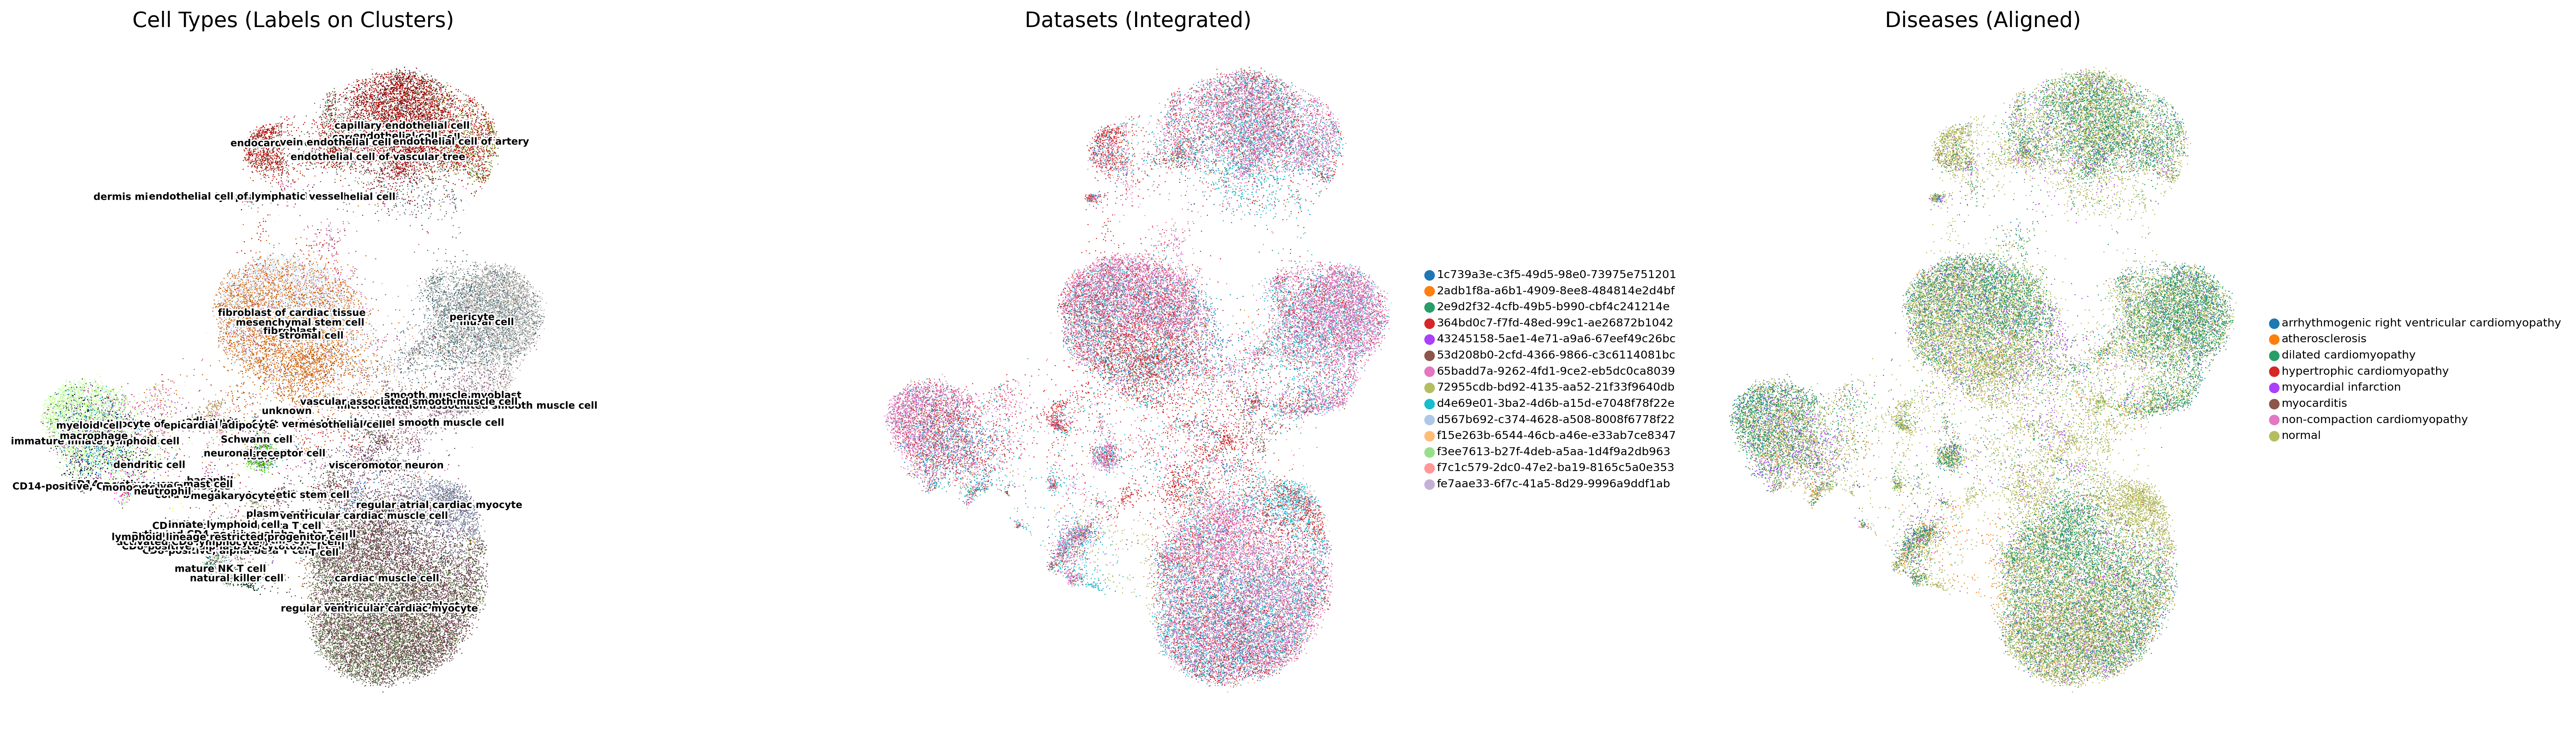

In [ ]:
# ═══════════════════════════════════════════════════════════════
# CELL 9 (Clean Layout): Plot UMAP Visualisation
# ═══════════════════════════════════════════════════════════════
import scanpy as sc
import matplotlib.pyplot as plt

# Premium figure aesthetics
sc.settings.set_figure_params(dpi=150, facecolor='white', frameon=False)

fig, axes = plt.subplots(1, 3, figsize=(24, 7))

# 1. Cell Types - Put labels directly on the clusters (clears legend clutter)
sc.pl.umap(
    adata_val,
    color="cell_type",
    legend_loc="on data",
    legend_fontsize=6.5,
    legend_fontoutline=2,
    ax=axes[0],
    show=False,
    title="Cell Types (Labels on Clusters)"
)

# 2. Datasets - Neatly in the right margin
sc.pl.umap(
    adata_val,
    color="dataset_id",
    legend_loc="right margin",
    legend_fontsize=7.5,
    ax=axes[1],
    show=False,
    title="Datasets (Integrated)"
)

# 3. Diseases - Neatly in the right margin
sc.pl.umap(
    adata_val,
    color="disease",
    legend_loc="right margin",
    legend_fontsize=7.5,
    ax=axes[2],
    show=False,
    title="Diseases (Aligned)"
)

plt.tight_layout()
plt.show()